In [1]:
# Point PriNCe at the FLUKA-derived photo-nuclear database (v1).
# Built by prince-fluka-utils — replaces the SOPHIA + PEANUT/TALYS
# split. The path below is the production v1 build on SATORI; override
# config.fluka_db_path / config.fluka_db_fname for a different machine.
import prince_cr.config
prince_cr.config.fluka_db_path = '/ceph/sharedfs/work/SATORI/anatoli/devel/UH-UHECR-Fluka-Prince/runs/2026-05-04_pfu-v1-prod'
prince_cr.config.fluka_db_fname = 'prince_db_v1.h5'


CUPY not found for GPU support. Degrading to MKL.


In [2]:
import os
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle as pickle

In [3]:
import prince_cr.config
from prince_cr import core, util, photonfields, cross_sections
from prince_cr import util as pru

# Setup and save prince_run objects

Before you create the kernel, you can change options in the config.  
See `prince/config.py` for a full list of options

In [4]:
prince_cr.config.x_cut = 1e-4
prince_cr.config.x_cut_proton = 1e-2
prince_cr.config.tau_dec_threshold = np.inf

### Now create the objects:
- Photonfield class
- Cross section class
- PriNCe core class, that will contain the cross section kernel

(The latter two take some time)

Note that TabulatedCrossSection will look for data in the database stored in `./prince/data/prince_db_05`

#### Photon field class

This is a combined photon field of CMB and Gilmore et al. EBL  
See classes in `prince/photonfields.py` for different options

In [5]:
%%time
pf = photonfields.CombinedPhotonField(
                [photonfields.CMBPhotonSpectrum, 
                 photonfields.CIBGilmore2D])

CPU times: user 2.01 ms, sys: 1.03 ms, total: 3.03 ms
Wall time: 10.9 ms


#### Cross section class

This is a combined cross section of `Talys` as low energy the `Sophia` superposition model at high energies
See classes in `prince/cross_sections.py` for different options

In [6]:
%%time
cs = cross_sections.FlukaPhotoNuclear()


CPU times: user 3min 27s, sys: 4.85 s, total: 3min 31s
Wall time: 20.1 s


#### Prince_run kernel

In [7]:
%%time
prince_run_talys = core.PriNCeRun(max_mass = 56, photon_field=pf, cross_sections=cs)

PriNCeRun::__init__(): initialising Energy grid


PhotoNuclearInteractionRate::_init_coupling_mat(): Initiating coupling matrix in (CSR) format


CPU times: user 17 s, sys: 1.58 s, total: 18.6 s
Wall time: 17.8 s


### Save the kernel for reuse

Now pickle the core class to some folder (it is a few GB large)  
**Adjust the path to some folder

In [8]:
%%time
target_path = "../" # Root directory of examples package
with open(target_path + 'prince_run_talys_test.ppo','wb') as thefile:
    pickle.dump(prince_run_talys, thefile, protocol = -1)

CPU times: user 453 ms, sys: 912 ms, total: 1.37 s
Wall time: 5.13 s


# Reload the model and test

In [9]:
%%time
with open(target_path + 'prince_run_talys_test.ppo','rb') as thefile:
    prince_run_talys = pickle.load(thefile)

CPU times: user 384 ms, sys: 1.33 s, total: 1.71 s
Wall time: 1.72 s


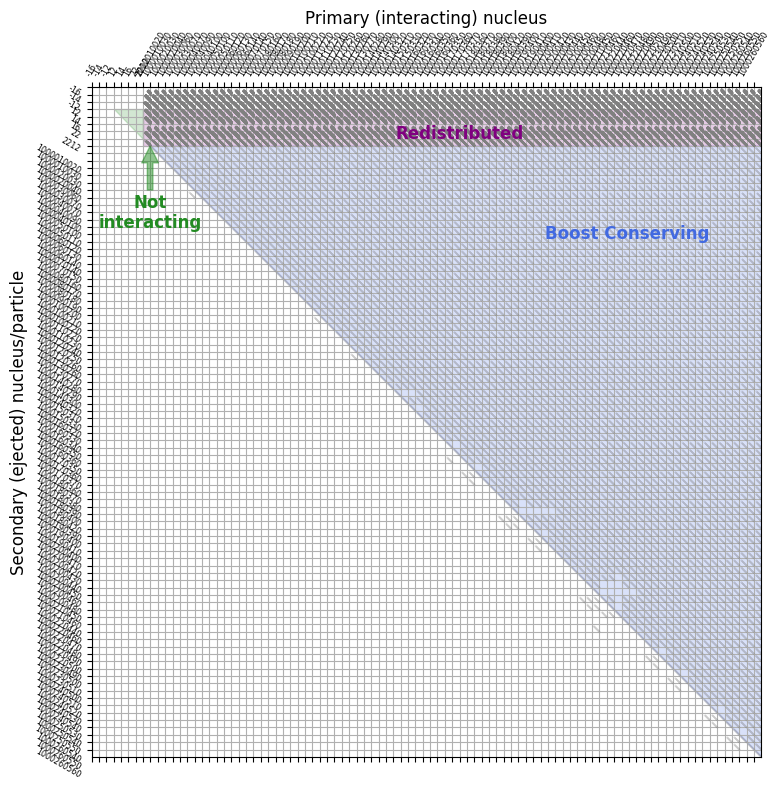

In [10]:
prince_run = prince_run_talys

precision = 0.# 1e-28
jac = prince_run.int_rates.get_hadr_jacobian(1.)

fig, ax = plt.subplots(1,1, figsize=(8,8))
 
photon = prince_run.spec_man.pdgid2sref[12]
proton = prince_run.spec_man.pdgid2sref[2212]
iron = prince_run.spec_man.pdgid2sref[1000260560]

rect = plt.Polygon([(proton.uidx(), proton.uidx()),
                    (iron.uidx(), iron.uidx()),
                    (iron.uidx(), proton.uidx())
                   ],
                    color = 'royalblue', alpha = 0.2)
plt.annotate('Boost Conserving', (6400,1750), 
             color = 'royalblue', ha = 'center', va = 'center', fontsize = 'large', fontweight = 'bold')

ax.add_patch(rect)
rect = plt.Polygon([(proton.lidx(), photon.lidx()),
                    (proton.lidx(), proton.uidx()),
                    (iron.uidx(), proton.uidx()),
                    (iron.uidx(), photon.lidx()),
                    ],
                    color = 'purple', alpha = 0.2)
ax.add_patch(rect)
plt.annotate('Redistributed', (4400,550), 
             color = 'purple', ha = 'center', va = 'center', fontsize = 'large', fontweight = 'bold')

rect = plt.Polygon([(photon.lidx(), photon.lidx()),
#                     (photon.lidx(), proton.lidx()),
                    (proton.lidx(), photon.lidx()),
                    (proton.lidx(), proton.lidx()),
                    ],
                    color = 'forestgreen', alpha = 0.2)
ax.add_patch(rect)
plt.annotate('Not\ninteracting', (700,700), xytext = (700,1500), arrowprops=dict(facecolor='forestgreen', edgecolor = 'forestgreen', shrink=0.01, alpha = 0.5),
             color = 'forestgreen', ha = 'center', va = 'center', fontsize = 'large', fontweight = 'bold')

plt.spy(jac, markersize=0.01, precision = precision, c ='gray')
# plt.imshow(np.log(np.abs(jac.todense())),origin="upper", interpolation='nearest',cmap='binary')

ticks, labels = zip(*[(s.lidx() , s.pdgid) for s in prince_run.spec_man.species_refs][::])

ax.set_xticks(ticks)
ax.set_xticklabels(labels,rotation =60.,fontsize='xx-small')
ax.set_yticks(ticks)
ax.set_yticklabels(labels,rotation =-30, fontsize='xx-small')

ax.set_xlabel(r'Primary (interacting) nucleus',fontsize='large')

ax.xaxis.set_label_position('top') 
ax.set_ylabel(r'Secondary (ejected) nucleus/particle',fontsize='large')
ax.grid()

plt.tight_layout()